In [1]:
import os

print(os.listdir("/content"))

['.config', 'AG News Classification Dataset.zip', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
with zipfile.ZipFile("/content/AG News Classification Dataset.zip","r") as zip_ref:
    zip_ref.extractall("/content/ag_news")


In [4]:
df = pd.read_csv(
    "/content/ag_news/train.csv",
    names=["Class","Title","Description"]
)

In [5]:
print(df.head())

print(df.info())

print(df.shape)

print(df.isnull().sum())


         Class                                              Title  \
0  Class Index                                              Title   
1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
4            3  Iraq Halts Oil Exports from Main Southern Pipe...   

                                         Description  
0                                        Description  
1  Reuters - Short-sellers, Wall Street's dwindli...  
2  Reuters - Private investment firm Carlyle Grou...  
3  Reuters - Soaring crude prices plus worries\ab...  
4  Reuters - Authorities have halted oil export\f...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120001 entries, 0 to 120000
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class        120001 non-null  object
 1   Title        1

In [6]:
df = df.dropna()

In [7]:
df["Text"] = df["Title"] + " " + df["Description"]

print(df.head())


         Class                                              Title  \
0  Class Index                                              Title   
1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
4            3  Iraq Halts Oil Exports from Main Southern Pipe...   

                                         Description  \
0                                        Description   
1  Reuters - Short-sellers, Wall Street's dwindli...   
2  Reuters - Private investment firm Carlyle Grou...   
3  Reuters - Soaring crude prices plus worries\ab...   
4  Reuters - Authorities have halted oil export\f...   

                                                Text  
0                                  Title Description  
1  Wall St. Bears Claw Back Into the Black (Reute...  
2  Carlyle Looks Toward Commercial Aerospace (Reu...  
3  Oil and Economy Cloud Sto

In [8]:
print(df["Class"].value_counts())

Class
3              30000
2              30000
4              30000
1              30000
Class Index        1
Name: count, dtype: int64


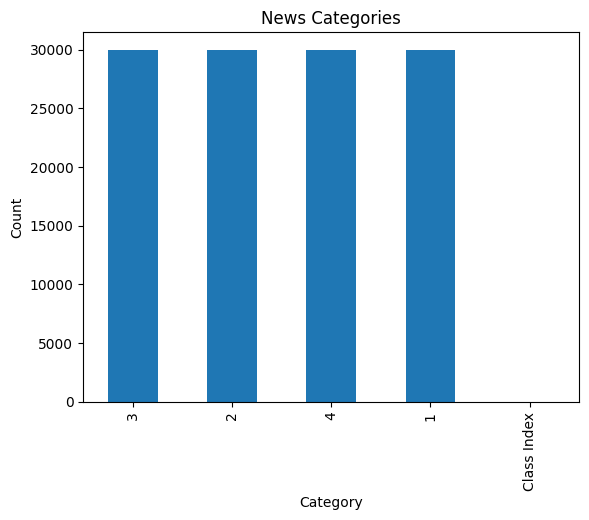

In [9]:
df["Class"].value_counts().plot(kind="bar")
plt.title("News Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [10]:
df["Text"] = df["Text"].str.lower()
df["Text"] = df["Text"].str.replace(r"[^a-zA-Z ]","",regex=True)
df["Text"] = df["Text"].str.replace(r"\s+"," ",regex=True)

In [11]:
X = df["Text"]
y = df["Class"]


In [12]:
cv = CountVectorizer(stop_words="english")
X = cv.fit_transform(X)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [14]:
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)


Accuracy : 0.9074621890754552


In [18]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

news = ["India won the cricket match by 8 wickets after an excellent performance."]
news = cv.transform(news)
prediction = model.predict(news)
print("Predicted Category :",prediction[0])

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      6047
           2       0.95      0.98      0.97      5872
           3       0.88      0.87      0.87      6079
           4       0.88      0.89      0.88      6002
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.91     24001
   macro avg       0.73      0.73      0.73     24001
weighted avg       0.91      0.91      0.91     24001

[[5420  189  284  154    0]
 [  47 5774   23   28    0]
 [ 219   64 5272  524    0]
 [ 221   43  424 5314    0]
 [   0    1    0    0    0]]
Predicted Category : 2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
news = ["Apple launched its latest AI powered smartphone with advanced technology."]

news = cv.transform(news)

prediction = model.predict(news)

print("Predicted Category :",prediction[0])


Predicted Category : 4


In [ ]:
print("News Classification Report")

print("Total Articles :",len(df))

print("World News :",len(df[df["Class"]==1]))

print("Sports News :",len(df[df["Class"]==2]))

print("Business News :",len(df[df["Class"]==3]))

print("Science/Technology News :",len(df[df["Class"]==4]))

print("Model Accuracy :",round(accuracy*100,2),"%")

========== News Classification Report ==========
Total Articles : 120001
World News : 0
Sports News : 0
Business News : 0
Science/Technology News : 0
Model Accuracy : 90.75 %
